## Árvores de regressão - exercícios 02

Este exercício será uma continuação do anterior, mesma base, mesmas variáveis - vamos tentar buscar a 'melhor árvore'.


*Atenção - Utilizar a base de dados em anexo que é a mesma base que utilizamos na atividade anterior! A base Boston, assim como para a primeira atividade foi descontinuada e não deve ser utilizada*

In [12]:
import pandas as pd

import seaborn as sns

from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

### 1. Execute os passos do exercício anterior, até que você tenha uma árvore de regressão predizendo o valor do imóvel na base de treinamento.

In [16]:
df = pd.read_csv('C:/Users/fabio.stampone/Documents/EBAC/Mod11/Pratique1/housing.csv')

# Verificar valores ausentes
valores_ausentes = df.isnull().sum()

# Tratar valores ausentes preenchendo com a mediana
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Converter variáveis categóricas em numéricas
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# Separar as variáveis independentes (X) e o alvo (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Dividir em conjuntos de treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar os dados preparados
print("Primeiras linhas de X_treino:")
print(X_treino.head())
print("\nPrimeiras linhas de y_treino:")
print(y_treino.head())

Primeiras linhas de X_treino:
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
14196    -117.03     32.71                33.0       3126.0           627.0   
8267     -118.16     33.77                49.0       3382.0           787.0   
17445    -120.48     34.66                 4.0       1897.0           331.0   
14265    -117.11     32.69                36.0       1421.0           367.0   
2271     -119.80     36.78                43.0       2382.0           431.0   

       population  households  median_income  ocean_proximity_INLAND  \
14196      2300.0       623.0         3.2596                   False   
8267       1314.0       756.0         3.8125                   False   
17445       915.0       336.0         4.1563                   False   
14265      1418.0       355.0         1.9425                   False   
2271        874.0       380.0         3.5542                    True   

       ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
141

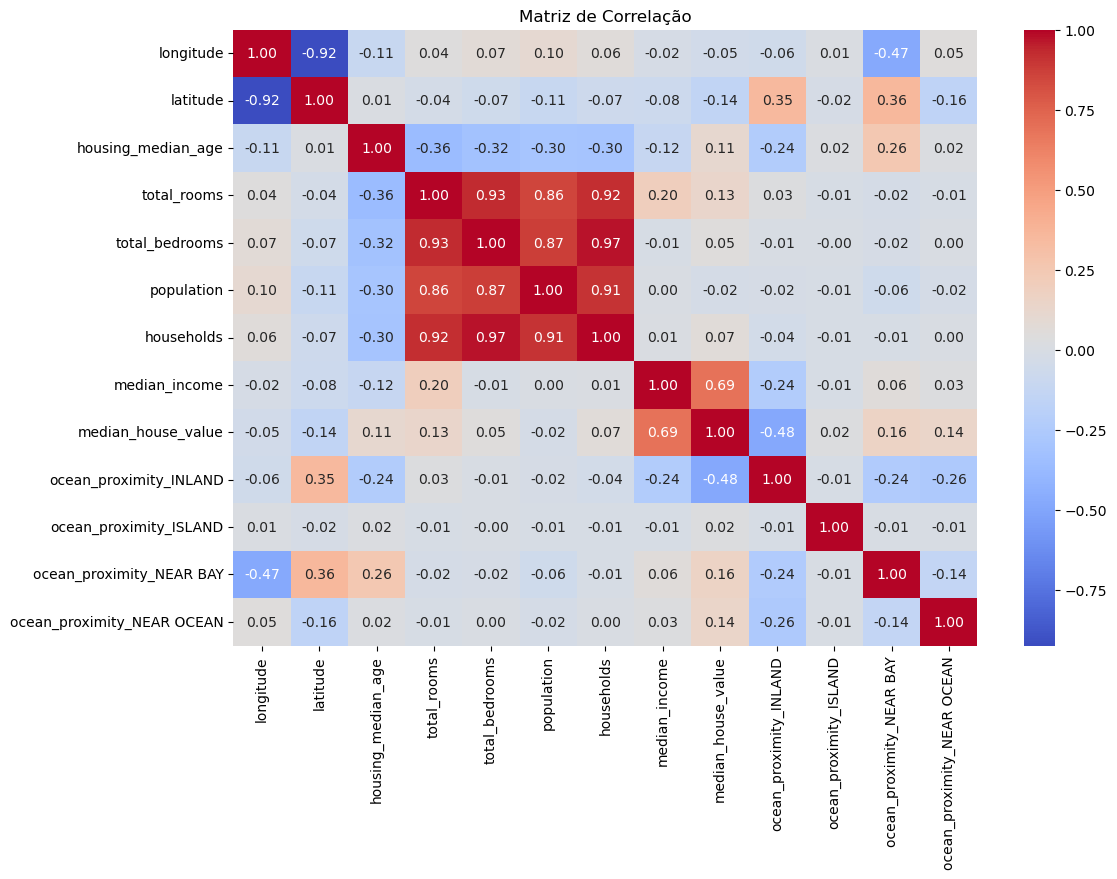

median_house_value            1.000000
median_income                 0.688075
ocean_proximity_NEAR BAY      0.160284
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
households                    0.065843
total_bedrooms                0.049457
ocean_proximity_ISLAND        0.023416
population                   -0.024650
longitude                    -0.045967
latitude                     -0.144160
ocean_proximity_INLAND       -0.484859
Name: median_house_value, dtype: float64


In [18]:
# Calcular a matriz de correlação
matriz_correlacao = df.corr()

# Visualizar a matriz de correlação
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlação")
plt.show()

# Identificar possíveis variáveis preditivas para o valor mediano das habitações
correlacoes_com_alvo = matriz_correlacao["median_house_value"].sort_values(ascending=False)
print(correlacoes_com_alvo)

In [20]:
# Dividir os dados em treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# Dividir o conjunto de treino em treino final (70% do treino) e validação (30% do treino)
X_treino_final, X_validacao, y_treino_final, y_validacao = train_test_split(X_treino, y_treino, test_size=0.3, random_state=42)

# Exibir tamanhos dos conjuntos
print("Tamanho do conjunto de treino final:", len(X_treino_final))
print("Tamanho do conjunto de validação:", len(X_validacao))
print("Tamanho do conjunto de teste:", len(X_teste))

Tamanho do conjunto de treino final: 11558
Tamanho do conjunto de validação: 4954
Tamanho do conjunto de teste: 4128


In [22]:
# Treinar uma árvore de decisão com profundidade máxima = 8
arvore_profundidade_8 = DecisionTreeRegressor(max_depth=8, random_state=42)
arvore_profundidade_8.fit(X_treino_final, y_treino_final)

# Fazer previsões no conjunto de validação
previsoes_profundidade_8 = arvore_profundidade_8.predict(X_validacao)

# Avaliar o desempenho
erro_profundidade_8 = mean_squared_error(y_validacao, previsoes_profundidade_8, squared=True) ** 0.5  # RMSE manual

# Treinar uma árvore de decisão com profundidade máxima = 2
arvore_profundidade_2 = DecisionTreeRegressor(max_depth=2, random_state=42)
arvore_profundidade_2.fit(X_treino_final, y_treino_final)

# Fazer previsões no conjunto de validação
previsoes_profundidade_2 = arvore_profundidade_2.predict(X_validacao)

# Avaliar o desempenho
erro_profundidade_2 = mean_squared_error(y_validacao, previsoes_profundidade_2, squared=True) ** 0.5  # RMSE manual

# Exibir os erros das duas árvores
print("Erro (RMSE) Árvore Profundidade 8:", erro_profundidade_8)
print("Erro (RMSE) Árvore Profundidade 2:", erro_profundidade_2)

Erro (RMSE) Árvore Profundidade 8: 64815.84800833478
Erro (RMSE) Árvore Profundidade 2: 83223.60750796605


C:\Users\fabio.stampone\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\fabio.stampone\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [24]:
# Calcular o MSE no conjunto de treino e teste para a árvore com profundidade máxima = 8
mse_treino_profundidade_8 = mean_squared_error(y_treino_final, arvore_profundidade_8.predict(X_treino_final))
mse_teste_profundidade_8 = mean_squared_error(y_teste, arvore_profundidade_8.predict(X_teste))

# Calcular o MSE no conjunto de treino e teste para a árvore com profundidade máxima = 2
mse_treino_profundidade_2 = mean_squared_error(y_treino_final, arvore_profundidade_2.predict(X_treino_final))
mse_teste_profundidade_2 = mean_squared_error(y_teste, arvore_profundidade_2.predict(X_teste))

# Exibir os MSEs
print("MSE Treino Árvore Profundidade 8:", mse_treino_profundidade_8)
print("MSE Teste Árvore Profundidade 8:", mse_teste_profundidade_8)
print("MSE Treino Árvore Profundidade 2:", mse_treino_profundidade_2)
print("MSE Teste Árvore Profundidade 2:", mse_teste_profundidade_2)

MSE Treino Árvore Profundidade 8: 3258109862.8670974
MSE Teste Árvore Profundidade 8: 4088221178.408431
MSE Treino Árvore Profundidade 2: 6789191835.620245
MSE Teste Árvore Profundidade 2: 6942061633.329117


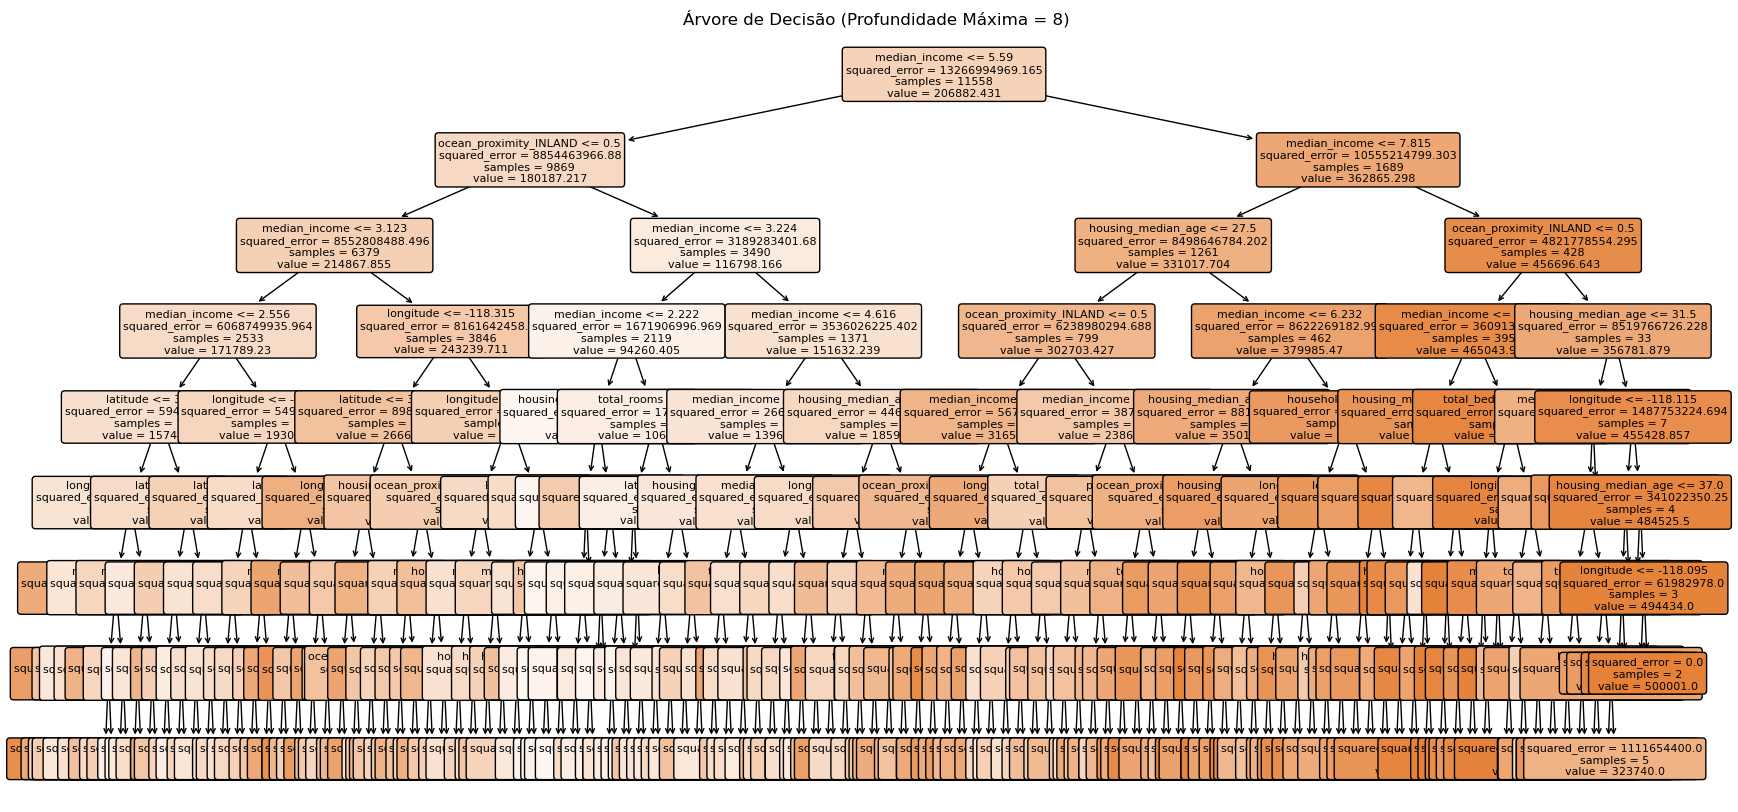

In [26]:
# Visualizar graficamente a árvore com profundidade máxima = 8
plt.figure(figsize=(20, 10))
plot_tree(arvore_profundidade_8, filled=True, feature_names=X.columns, rounded=True, fontsize=8)
plt.title("Árvore de Decisão (Profundidade Máxima = 8)")
plt.show()

In [34]:
# Criar e treinar o modelo de árvore de decisão na base de treino original
arvore_profundidade_8 = DecisionTreeRegressor(max_depth=8, random_state=42)
arvore_profundidade_8.fit(X_treino_final, y_treino_final)

# Fazer previsões na base de treinamento (treino final do código original)
previsoes_treino_final = arvore_profundidade_8.predict(X_treino_final)

# Avaliar o desempenho na base de treinamento
erro_rmse_treino_final = mean_squared_error(y_treino_final, previsoes_treino_final, squared=False)  # RMSE

# Exibir o RMSE na base de treinamento
print("Erro (RMSE) na base de treinamento (treino final):", erro_rmse_treino_final)

Erro (RMSE) na base de treinamento (treino final): 57079.8551405581


C:\Users\fabio.stampone\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### 2.  Calcule o caminho indicado pelos CCP-alfas dessa árvore.

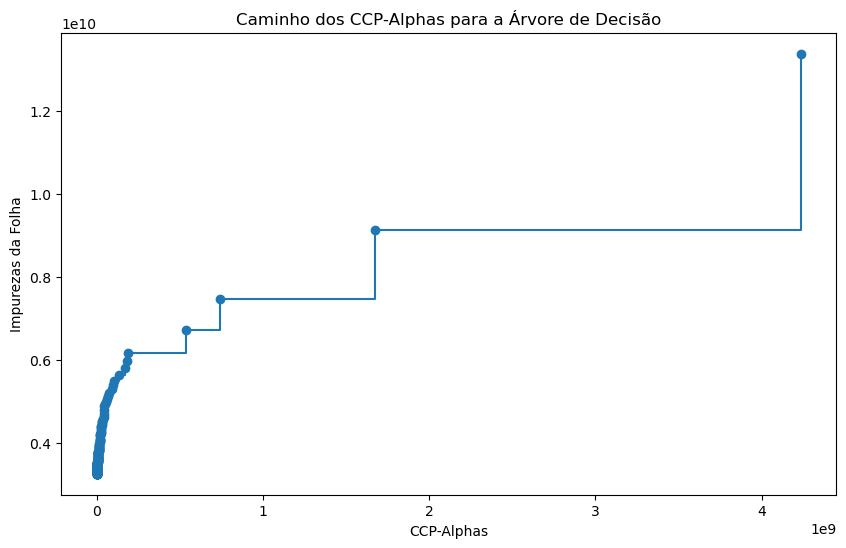

array([0.00000000e+00, 2.61900436e+03, 1.89256298e+04, 4.34959423e+04,
       6.97674419e+04, 8.09378028e+04, 8.21950703e+04, 1.24876112e+05,
       1.44381460e+05, 1.48270349e+05, 1.60803507e+05, 1.66409884e+05,
       2.15752431e+05, 2.31838966e+05, 2.52402255e+05, 2.73801781e+05,
       3.03281977e+05, 3.06388794e+05, 3.42858829e+05, 3.79792125e+05,
       4.13135190e+05, 4.14396923e+05, 4.16817897e+05, 4.28366663e+05,
       4.36782386e+05, 4.50270854e+05, 4.64195762e+05, 4.97279215e+05,
       5.00268654e+05, 5.26396798e+05, 5.37065872e+05, 5.39635429e+05,
       5.45288746e+05, 5.51932325e+05, 5.67514838e+05, 5.97909547e+05,
       6.63441876e+05, 6.68928173e+05, 6.72070214e+05, 6.74873117e+05,
       6.77602406e+05, 6.98352878e+05, 7.12728292e+05, 7.42299235e+05,
       7.65388778e+05, 7.75007377e+05, 7.75669221e+05, 7.79389356e+05,
       8.47884672e+05, 8.62074913e+05, 8.63384824e+05, 8.63576490e+05,
       9.48713462e+05, 9.50674322e+05, 9.85359008e+05, 9.85709888e+05,
      

In [38]:
# Calcular os CCP-alfas
caminho_ccp = arvore_regressao.cost_complexity_pruning_path(X_treino, y_treino)
ccp_alfas = caminho_ccp.ccp_alphas
impurezas_folha = caminho_ccp.impurities

# Visualizar o caminho dos CCP-alfas
plt.figure(figsize=(10, 6))
plt.plot(ccp_alfas, impurezas_folha, marker="o", drawstyle="steps-post")
plt.xlabel("CCP-Alphas")
plt.ylabel("Impurezas da Folha")
plt.title("Caminho dos CCP-Alphas para a Árvore de Decisão")
plt.show()

# Exibir os valores de CCP-Alphas
ccp_alfas


### 3. Paca cada valor de alpha obtido no item 2, treine uma árvore com o respectivo alfa, e guarde essa árvore em uma lista.

In [40]:
# Treinar uma árvore para cada valor de alfa obtido e armazená-las em uma lista
arvores_podadas = []

for alfa in ccp_alfas:
    arvore = DecisionTreeRegressor(random_state=42, ccp_alpha=alfa)
    arvore.fit(X_treino, y_treino)
    arvores_podadas.append(arvore)

# Exibir a quantidade de árvores treinadas
print(f"Número de árvores treinadas: {len(arvores_podadas)}")


Número de árvores treinadas: 211


### 4. Para cada árvore na lista, calcule o MSE da árvore.

In [42]:
# Calcular o MSE para cada árvore na lista e armazenar os valores
mse_arvores = []

for arvore in arvores_podadas:
    previsoes = arvore.predict(X_teste)  # Fazer previsões no conjunto de teste
    mse = mean_squared_error(y_teste, previsoes)  # Calcular o MSE
    mse_arvores.append(mse)

# Exibir os MSEs calculados
print(mse_arvores)


[4865868836.95906, 4864949041.360159, 4835587533.740843, 4825337264.367578, 4777757872.092516, 4773736049.223936, 4776312767.831026, 4715372926.905013, 4684780887.30493, 4677851953.911749, 4680673829.2829895, 4677020463.454483, 4620286163.223671, 4629459647.458279, 4615017570.602653, 4609542154.38684, 4592801265.597432, 4589182868.368363, 4555985459.263028, 4520884730.428881, 4472147714.328611, 4472214456.41312, 4470202928.10449, 4452152490.241131, 4459324532.955398, 4441663821.362161, 4434009666.558511, 4430869923.544914, 4429202048.484765, 4383643203.349667, 4374221516.425643, 4374401121.415332, 4364285173.590496, 4346456087.849202, 4361977615.535051, 4368787900.705093, 4335730413.525037, 4328781354.19187, 4326898621.377965, 4326434416.174963, 4326434416.174963, 4318358120.919948, 4298725243.516348, 4283774897.2109613, 4276254969.047072, 4266688578.3528724, 4267840581.437231, 4269948461.7611947, 4268246444.2800198, 4247863547.645309, 4247863547.645309, 4254244270.755774, 4207398485.4

### 5. Monte um gráfico do MSE pelo alpha, escolha um valor de alpha perto do ponto de mínimo do MSE

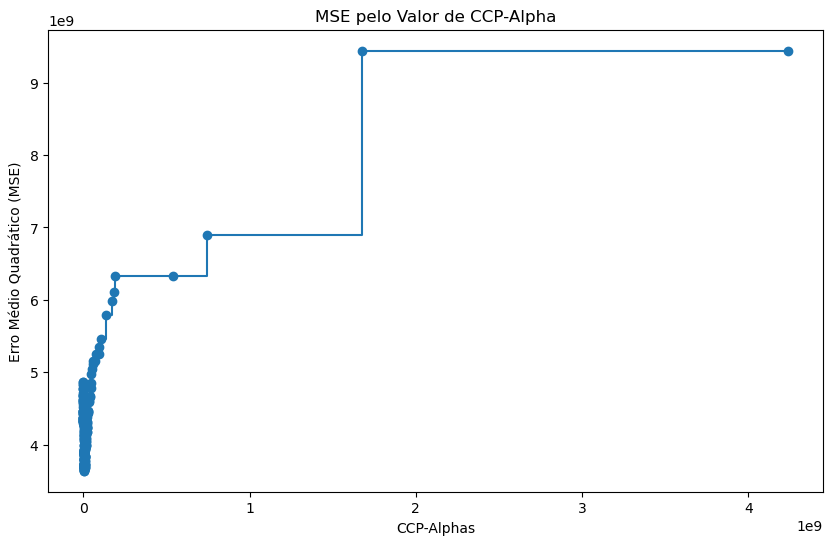

O melhor valor de alfa próximo ao mínimo do MSE é: 5175466.365602359


In [44]:
# Criar o gráfico do MSE pelo alfa
plt.figure(figsize=(10, 6))
plt.plot(ccp_alfas, mse_arvores, marker="o", drawstyle="steps-post")
plt.xlabel("CCP-Alphas")
plt.ylabel("Erro Médio Quadrático (MSE)")
plt.title("MSE pelo Valor de CCP-Alpha")
plt.show()

# Encontrar o índice do menor MSE
indice_melhor_alfa = mse_arvores.index(min(mse_arvores))
melhor_alfa = ccp_alfas[indice_melhor_alfa]

# Exibir o melhor valor de alfa
print(f"O melhor valor de alfa próximo ao mínimo do MSE é: {melhor_alfa}")


### 6. Calcule o R-quadrado dessa árvore encontrada no item acima

In [46]:
# Selecionar a árvore correspondente ao melhor valor de alfa
melhor_arvore = arvores_podadas[indice_melhor_alfa]

# Calcular o R-quadrado (coeficiente de determinação) da árvore selecionada
r_quadrado = melhor_arvore.score(X_teste, y_teste)

# Exibir o R-quadrado
print(f"O R-quadrado da árvore com o melhor alfa ({melhor_alfa}) é: {r_quadrado}")


O R-quadrado da árvore com o melhor alfa (5175466.365602359) é: 0.7221561338721445


### 7. Visualize esta árvore.

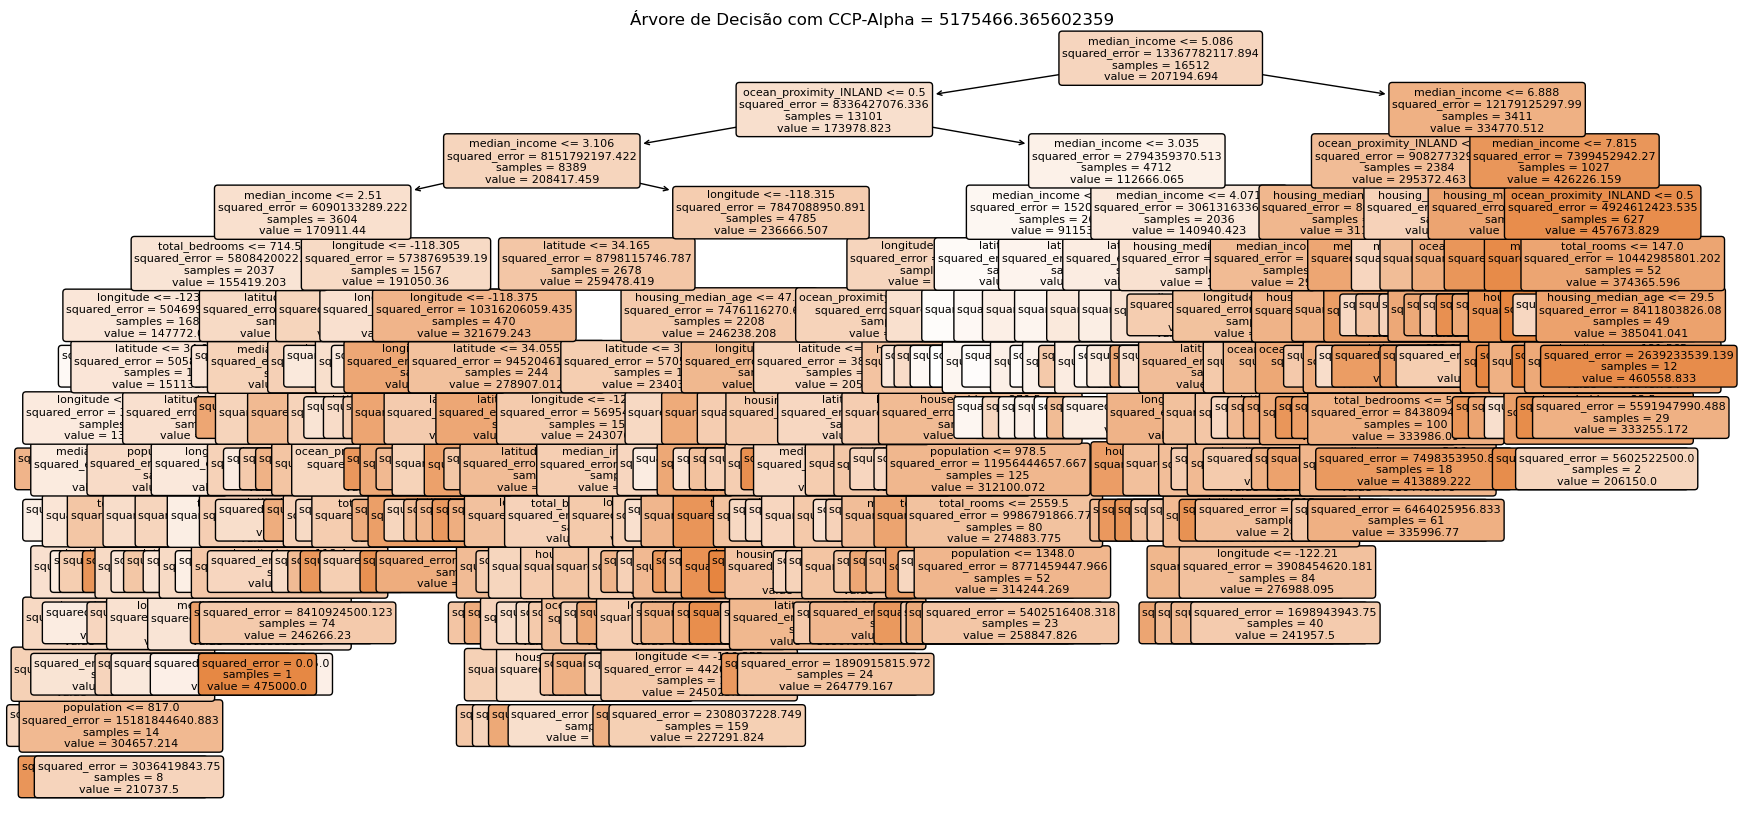

In [50]:
# Visualizar graficamente a árvore com o melhor alfa
plt.figure(figsize=(20, 10))
plot_tree(melhor_arvore, filled=True, feature_names=X.columns, rounded=True, fontsize=8)
plt.title(f"Árvore de Decisão com CCP-Alpha = {melhor_alfa}")
plt.show()
